<a href="https://colab.research.google.com/github/anaberereta-hue/Reto1-Matem-tica3/blob/main/Superficie_de_precios_de_propiedades.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Reto 1 - Superficie de precios de propiedades**

###Integrantes:


*   Luciana Aldás
*   Anahí Real
*   Francisco Narváez

###Fecha: 24 de mayo del 2026



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Carga y lectura del archivo "Train.csv"
df = pd.read_csv('https://raw.githubusercontent.com/anaberereta-hue/Reto1-Matem-tica3/103384e86650a3a804186ad71131a784107005f4/train.csv')

print("Primeras 5 filas del DataFrame cargado:")
display(df.head())

Primeras 5 filas del DataFrame cargado:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Ver las estadísticas descriptivas de todo el dataset
print("Estadísticas descriptivas generales:")
print(df.describe())


Estadísticas descriptivas generales:
                Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20

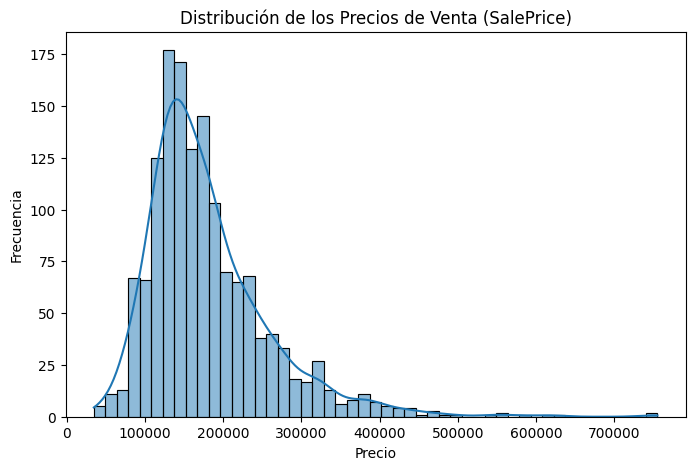

In [ ]:
# Graficar la distribución de la variable objetivo (SalePrice)
plt.figure(figsize=(8, 5))
sns.histplot(df['SalePrice'], kde=True) #kde es para ver la curva del histograma (distribucion Poisson)
plt.title('Distribución de los Precios de Venta (SalePrice)')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

Matriz de correlación:
             SalePrice  GrLivArea  OverallQual  GarageArea  TotalBsmtSF
SalePrice     1.000000   0.708624     0.790982    0.623431     0.613581
GrLivArea     0.708624   1.000000     0.593007    0.468997     0.454868
OverallQual   0.790982   0.593007     1.000000    0.562022     0.537808
GarageArea    0.623431   0.468997     0.562022    1.000000     0.486665
TotalBsmtSF   0.613581   0.454868     0.537808    0.486665     1.000000


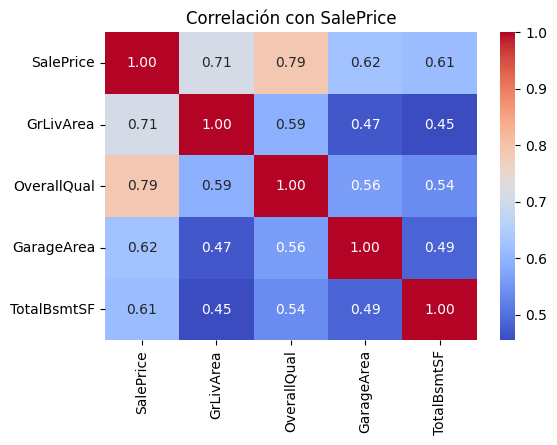

In [ ]:
# Seleccionamos algunas variables numéricas candidatas
variables_interes = ['SalePrice', 'GrLivArea', 'OverallQual', 'GarageArea', 'TotalBsmtSF'] # 'GarArea' corregido a 'GarageArea'
matriz_corr = df[variables_interes].corr()

# Mostrar la matriz de correlación en texto
print("Matriz de correlación:")
print(matriz_corr)

# Graficar la matriz con un mapa de calor
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación con SalePrice')
plt.show()

In [ ]:
# Definimos las variables independientes (X) y dependiente (y)
X = df[['GrLivArea', 'OverallQual']]
y = df['SalePrice']

# Creamos las características polinomiales de grado 2
# Esto generará: x1, x2, x1^2, x2^2 y x1*x2
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Ajustamos el modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X_poly, y)

# Imprimimos los resultados que nos pide el reporte
print("--- RESULTADOS DEL MODELO ---")
print(f"Intercepto (Beta 0): {modelo.intercept_}")
print(f"Coeficientes (Beta 1 a Beta 5): {modelo.coef_}")
print(f"R^2 del modelo: {modelo.score(X_poly, y)}")

--- RESULTADOS DEL MODELO ---
Intercepto (Beta 0): 128534.22450247873
Coeficientes (Beta 1 a Beta 5): [ 1.95789017e+01 -3.55898092e+04 -3.33895899e-02  2.40647248e+01
  2.37479283e+03]
R^2 del modelo: 0.7706007228644699
